# Parte 3 — Experimento A: DistilBERT
### Workshop: Clasificación de Emociones en Twitter

**Modelo:** `distilbert-base-uncased`  
**Pre-entrenamiento:** Wikipedia + BookCorpus (texto formal)  
**Tokenizador:** WordPiece

Este es nuestro **baseline**. Pre-entrenado en texto formal, sin conocimiento específico del lenguaje de Twitter.

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [1]:
import os, pathlib

# Ensure we run from the notebook's directory so relative %%run paths resolve
_nb_dir = pathlib.Path("/teamspace/studios/this_studio/deep-learning-mjbv-20261/Workshop 4 - NLP")
if not (_nb_dir / "tweeteval-part-2-pipeline.ipynb").exists():
    raise FileNotFoundError(f"Cannot find pipeline notebook in {_nb_dir}")
os.chdir(_nb_dir)

%run tweeteval-part-2-pipeline.ipynb

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


## Configuración del experimento

In [2]:
MODEL_CHECKPOINT = "distilbert-base-uncased"
HF_REPO = "majonator/tweeteval-emotion-distilbert"
LR = 2e-5

### 📝 TODO 3.1 — Tokenizar el dataset con DistilBERT

Usa `make_tokenized_dataset` con el tokenizador correcto y guarda el resultado en `ds_distilbert`.

In [3]:
tok_distilbert = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
ds_distilbert  = make_tokenized_dataset(tok_distilbert)
print(ds_distilbert)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 374
    })
})


### 📝 TODO 3.2 — Cargar el modelo y contar parámetros

In [4]:
model_distilbert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

total_params = sum(p.numel() for p in model_distilbert.parameters())
trainable_params = sum(p.numel() for p in model_distilbert.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     66,956,548
Trainable parameters: 66,956,548


### 📝 TODO 3.3 — Entrenar y evaluar

In [5]:
trainer_distilbert = make_trainer(
    model = model_distilbert,
    tokenizer = tok_distilbert,
    tokenized_ds = ds_distilbert,
    output_dir = "./checkpoints/distilbert",
    lr = LR,
)
trainer_distilbert.train()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.885903,0.761139,0.538655,0.713904
2,0.572405,0.608748,0.711364,0.775401
3,0.380811,0.632251,0.709560,0.767380
4,0.316013,0.614489,0.742369,0.796791
5,0.244685,0.620875,0.734598,0.794118


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=510, training_loss=0.5620104186675128, metrics={'train_runtime': 1382.0629, 'train_samples_per_second': 11.783, 'train_steps_per_second': 0.369, 'total_flos': 188369926036488.0, 'train_loss': 0.5620104186675128, 'epoch': 5.0})

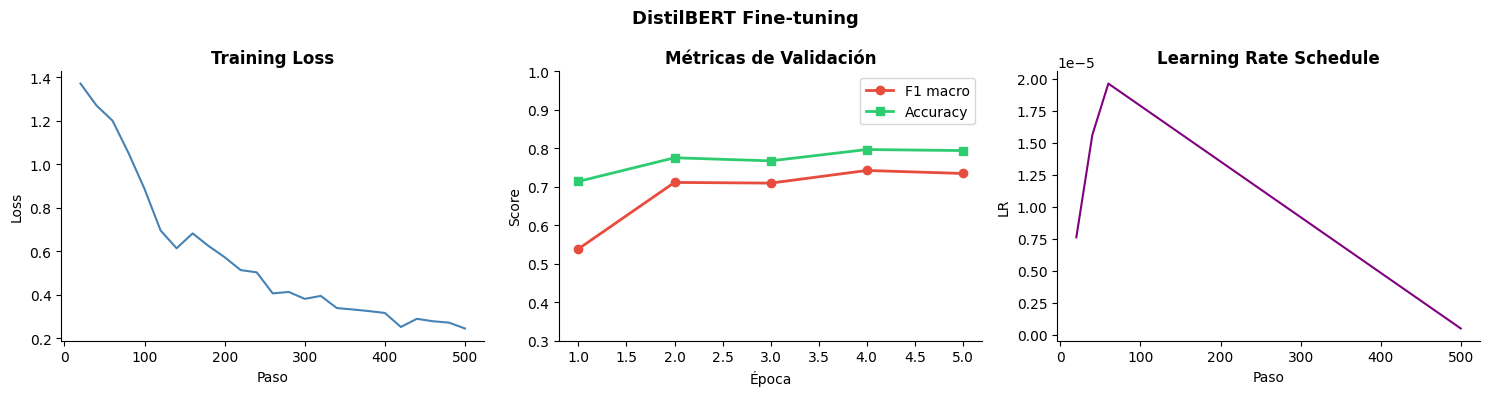

In [6]:
plot_training_curves(trainer_distilbert, title="DistilBERT Fine-tuning")

De las curvas de entrenamiento anteriores podemos notar que la función de pérdida desciende de forma constante en todas las épocas, psando de aproximadamente de 1.4 en el primer paso a 0.2 al final del entrenamiento, lo que indica que el modelo se ajustó cada vez más a los datos de entrenamiento. Por otro lado, el F1 macro da un saldo grande en la época 2, pasando de 0.54 a 0.71, y a partir de este punto, la mejora es marginal y fluctúa, lo que confirma que el modelo converge en torno a F1≈0.74. Finalmente, la gráfica del *learning rate schedule* muestra que hubo un breve calentamiento inicial donde la tasa de aprendizaje aumentó rápidamente hasta su máximo, pero luego de esto disminuyó progresenivamente hasta casi 0, ayudando a estabilizar el entrenamiento y mejorar la convergencia del modelo.

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



  Test — DistilBERT
              precision    recall  f1-score   support

       anger     0.8535    0.8459    0.8497       558
         joy     0.8113    0.8045    0.8079       358
    optimism     0.5929    0.5447    0.5678       123
     sadness     0.7775    0.8141    0.7954       382

    accuracy                         0.8008      1421
   macro avg     0.7588    0.7523    0.7552      1421
weighted avg     0.7999    0.8008    0.8002      1421



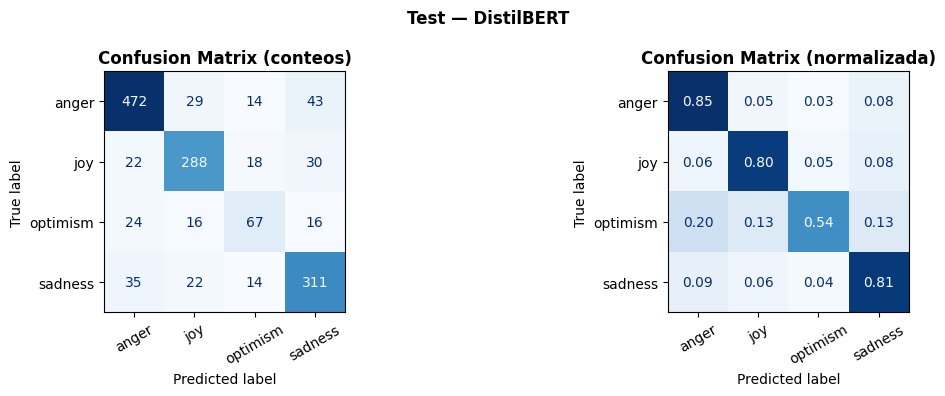

In [7]:
metrics_distilbert = full_evaluation(trainer_distilbert, ds_distilbert["test"],
                                     model_name="DistilBERT")

El modelo DistilBERT muestra un buen desempeño general (f1-score ≈ 0.80), destacándose en las clases anger, joy y sadness con métricas balanceadas, mientras que optimism presenta el peor rendimiento, evidenciando mayor confusión con otras clases. La matriz de confusión confirma que los errores se concentran principalmente en esta categoría, lo que sugiere dificultad para capturar sus patrones. 

## Push to Hub

In [8]:
# Requiere: huggingface-cli login  (o haber cargado el token con python-dotenv)
trainer_distilbert.model.push_to_hub(
    HF_REPO,
    commit_message="DistilBERT fine-tuning — TweetEval emotion",
)
tok_distilbert.push_to_hub(HF_REPO)
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Modelo publicado en: https://huggingface.co/majonator/tweeteval-emotion-distilbert
